# Model Merging — Results Analysis
Evaluates `magnitude_prune`, `ties`, and `dare_ties` on **GSM8K** (math) and **ARC** (science).

In [12]:
!pip install -q datasets

In [13]:
import json, re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from datasets import load_dataset

## 1. Load Ground Truth

In [14]:
dataset = load_dataset("MonicaHuang/ML2025_HW9")

# No ground-truth labels in the dataset (withheld for grading)
# Fields: id, task_name, instruction, question, options
questions = {
    "GSM8K": {d["id"]: d for d in dataset["GSM8K"]},
    "ARC":   {d["id"]: d for d in dataset["ARC"]},
}
print("GSM8K samples:", len(questions["GSM8K"]))
print("ARC   samples:", len(questions["ARC"]))
print("Sample:", dataset["GSM8K"][0])


GSM8K samples: 200
ARC   samples: 200
Sample: {'id': 'gsm8k_2', 'task_name': 'GSM8K', 'instruction': 'You are given a math question and four answer options (associated with "A", "B", "C", "D"). Your task is to carefully analyze the problem, apply logical reasoning, and select the correct answer. There is only one correct answer for each question.', 'question': 'A robe takes 2 bolts of blue fiber and half that much white fiber.  How many bolts in total does it take?', 'options': {'A': '5', 'B': '0', 'C': '1', 'D': '3'}}


## 2. Load Results

In [15]:
OUTPUT_DIR = Path("outputs")
METHODS    = ["magnitude_prune", "ties", "dare_ties"]
TASKS      = ["GSM8K", "ARC"]
FILENAME   = "w_1.0_0.4_d_0.2_result.json"

raw = {}  # raw[method][task] = list of {id, response}
for method in METHODS:
    raw[method] = {}
    for task in TASKS:
        path = OUTPUT_DIR / method / task / FILENAME
        with open(path) as f:
            raw[method][task] = json.load(f)
        print(f"{method:20s} | {task}: {len(raw[method][task])} samples loaded")

magnitude_prune      | GSM8K: 200 samples loaded
magnitude_prune      | ARC: 200 samples loaded
ties                 | GSM8K: 200 samples loaded
ties                 | ARC: 200 samples loaded
dare_ties            | GSM8K: 200 samples loaded
dare_ties            | ARC: 200 samples loaded


## 3. Answer Extraction\nThe model outputs free-form reasoning then concludes with `(X)`. We take the **last** `(A-D)` match.

In [16]:
def extract_answer(response: str):
    matches = re.findall(r'\(([A-D])\)', response)
    return matches[-1] if matches else None

# Sanity-check
sample = raw["dare_ties"]["GSM8K"][0]
print(f"ID       : {sample['id']}")
print(f"Response : {sample['response'][:200]}...")
print(f"Predicted: {extract_answer(sample['response'])}")


ID       : gsm8k_2
Response : Great, let's solve this math question together!

To find the total number of bolts needed to make a robe, we need to use the information provided in the question.

The question states that a robe take...
Predicted: D


## 4. Prediction Summary per Method & Task

In [17]:
records = []
preds_store = {}  # preds_store[method][task] = list of predicted labels

for method in METHODS:
    preds_store[method] = {}
    for task in TASKS:
        preds = [extract_answer(r["response"]) for r in raw[method][task]]
        preds_store[method][task] = preds
        total   = len(preds)
        no_pred = sum(p is None for p in preds)
        dist    = pd.Series([p or "None" for p in preds]).value_counts().reindex(
                      ["A","B","C","D","None"], fill_value=0)
        records.append({
            "method": method, "task": task,
            "total": total, "no_pred": no_pred,
            "parse_rate": f"{(total-no_pred)/total:.1%}",
            **{f"pred_{k}": v for k, v in dist.items()}
        })

df = pd.DataFrame(records)
display(df)


,method,task,total,no_pred,parse_rate,pred_A,pred_B,pred_C,pred_D,pred_None
0,magnitude_prune,GSM8K,200,1,99.5%,79,29,28,63,1
1,magnitude_prune,ARC,200,1,99.5%,71,53,58,17,1
2,ties,GSM8K,200,1,99.5%,70,26,37,66,1
3,ties,ARC,200,0,100.0%,60,45,59,36,0
4,dare_ties,GSM8K,200,11,94.5%,111,27,17,34,11
5,dare_ties,ARC,200,3,98.5%,33,35,49,80,3


## 5. Detailed Stats — No longer applicable (no ground truth)\n## 5. Prediction Distribution Plots

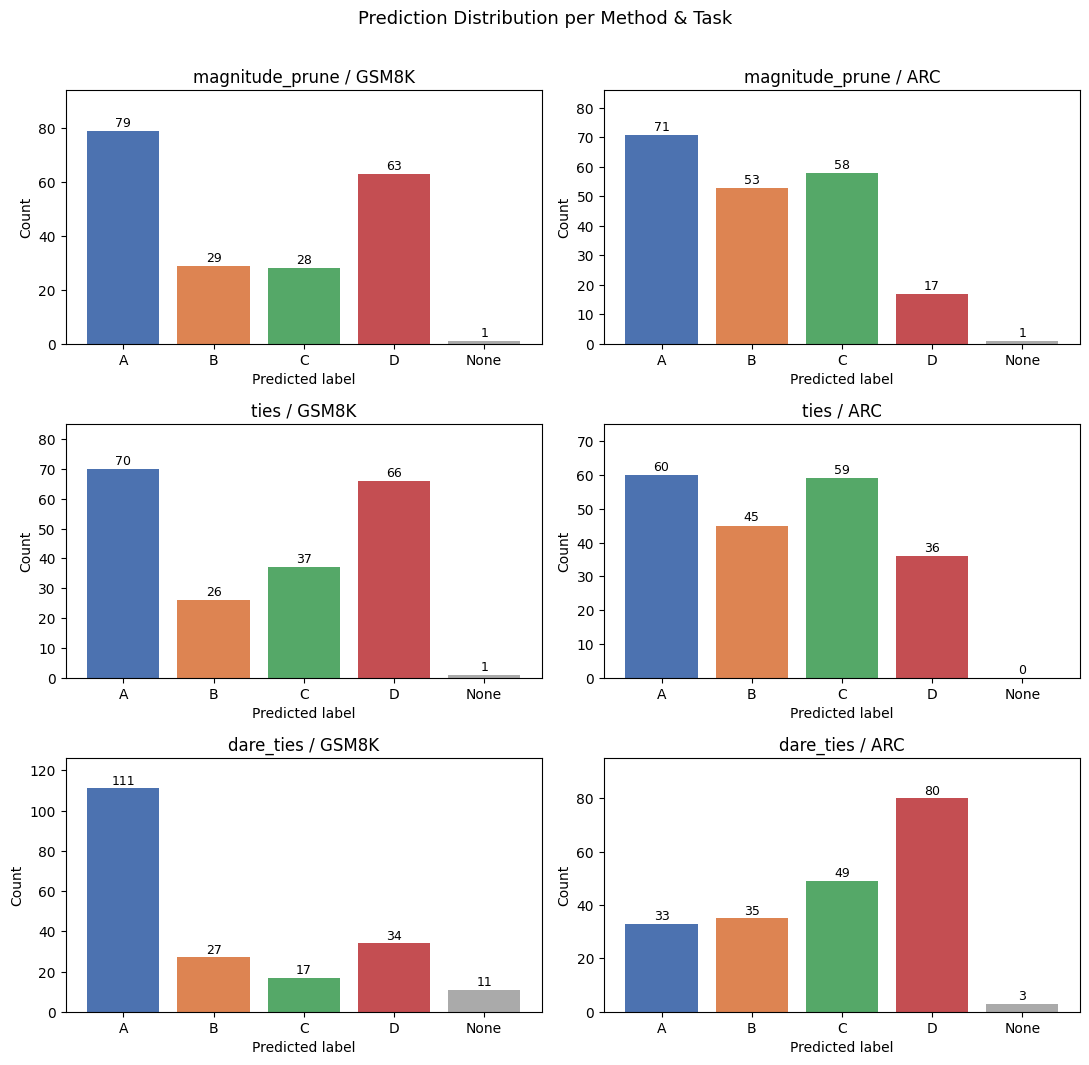

In [18]:
fig, axes = plt.subplots(len(METHODS), len(TASKS), figsize=(11, 3.5*len(METHODS)), sharey=False)

for i, method in enumerate(METHODS):
    for j, task in enumerate(TASKS):
        preds = preds_store[method][task]
        counts = pd.Series([p or "None" for p in preds]).value_counts() \
                   .reindex(["A","B","C","D","None"], fill_value=0)
        bars = axes[i][j].bar(counts.index, counts.values,
                               color=["#4C72B0","#DD8452","#55A868","#C44E52","#AAAAAA"])
        for bar in bars:
            axes[i][j].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                            str(int(bar.get_height())), ha="center", va="bottom", fontsize=9)
        axes[i][j].set_title(f"{method} / {task}")
        axes[i][j].set_xlabel("Predicted label")
        axes[i][j].set_ylabel("Count")
        axes[i][j].set_ylim(0, max(counts.values) + 15)

plt.suptitle("Prediction Distribution per Method & Task", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("prediction_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Method Agreement — Do methods predict the same answers?

In [19]:
from itertools import combinations

print(f"{'Pair':<40} {'Task':<8} {'Agreement':>10}")
print("-" * 62)
for task in TASKS:
    ids = [r["id"] for r in raw[METHODS[0]][task]]
    for m1, m2 in combinations(METHODS, 2):
        p1 = preds_store[m1][task]
        p2 = preds_store[m2][task]
        agree = sum(a == b for a, b in zip(p1, p2))
        print(f"{m1} vs {m2:<20} {task:<8} {agree}/{len(ids)} ({agree/len(ids):.1%})")
    print()


Pair                                     Task      Agreement
--------------------------------------------------------------
magnitude_prune vs ties                 GSM8K    108/200 (54.0%)
magnitude_prune vs dare_ties            GSM8K    87/200 (43.5%)
ties vs dare_ties            GSM8K    89/200 (44.5%)

magnitude_prune vs ties                 ARC      153/200 (76.5%)
magnitude_prune vs dare_ties            ARC      86/200 (43.0%)
ties vs dare_ties            ARC      83/200 (41.5%)



## 7. Disagreement Examples — Where do methods differ?

In [20]:
N_SHOW = 3  # number of disagreement examples to show per task

for task in TASKS:
    print(f"\n{'='*60}\n{task} — samples where methods disagree\n{'='*60}")
    ids = [r["id"] for r in raw[METHODS[0]][task]]
    shown = 0
    for idx, qid in enumerate(ids):
        votes = {m: preds_store[m][task][idx] for m in METHODS}
        if len(set(votes.values())) > 1:
            q = questions[task].get(qid, {})
            print(f"\nID: {qid}")
            print(f"Q : {q.get('question','')}")
            opts = q.get('options', {})
            for k, v in opts.items():
                print(f"    ({k}) {v}")
            for m, pred in votes.items():
                print(f"  {m:20s} → {pred}")
            shown += 1
        if shown >= N_SHOW:
            break



GSM8K — samples where methods disagree

ID: gsm8k_13
Q : Carlos is planting a lemon tree. The tree will cost $90 to plant. Each year it will grow 7 lemons, which he can sell for $1.5 each. It costs $3 a year to water and feed the tree. How many years will it take before he starts earning money on the lemon tree?
    (A) 13
    (B) 21
    (C) 79.5
    (D) 1
  magnitude_prune      → D
  ties                 → A
  dare_ties            → A

ID: gsm8k_17
Q : Two trains leave San Rafael at the same time. They begin traveling westward, both traveling for 80 miles. The next day, they travel northwards, covering 150 miles. What's the distance covered by each train in the two days?
    (A) 230
    (B) 0
    (C) 150
    (D) 330
  magnitude_prune      → A
  ties                 → C
  dare_ties            → B

ID: gsm8k_51
Q : Lloyd has an egg farm. His chickens produce 252 eggs per day and he sells them for $2 per dozen. How much does Lloyd make on eggs per week?
    (A) 294
    (B) 312
    (C) 3

In [21]:
# Majority-vote ensemble: pick the answer chosen by >= 2 methods
print("Majority-vote ensemble predictions (first 10 per task):\n")
for task in TASKS:
    print(f"--- {task} ---")
    ids = [r["id"] for r in raw[METHODS[0]][task]]
    ensemble = []
    for idx, qid in enumerate(ids):
        votes = [preds_store[m][task][idx] for m in METHODS]
        valid = [v for v in votes if v is not None]
        majority = pd.Series(valid).mode()
        ensemble.append(majority[0] if len(majority) else None)
    no_consensus = sum(1 for e, v in zip(ensemble, zip(*[preds_store[m][task] for m in METHODS]))
                       if len(set(v)) == len(METHODS))
    print(f"  No-consensus (all different): {no_consensus}/{len(ids)}")
    print(f"  Unparseable after voting    : {sum(e is None for e in ensemble)}/{len(ids)}")
    print(f"  Sample predictions          : {ensemble[:10]}\n")


Majority-vote ensemble predictions (first 10 per task):

--- GSM8K ---
  No-consensus (all different): 28/200
  Unparseable after voting    : 0/200
  Sample predictions          : ['D', 'A', 'A', 'A', 'A', 'D', 'B', 'A', 'A', 'B']

--- ARC ---
  No-consensus (all different): 14/200
  Unparseable after voting    : 0/200
  Sample predictions          : ['B', 'A', 'B', 'A', 'C', 'A', 'A', 'C', 'D', 'A']

